# Wine Quality Predicting

## 1) Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
%matplotlib inline

In [2]:
wine = pd.read_csv('data.csv')
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


## 2) EDA

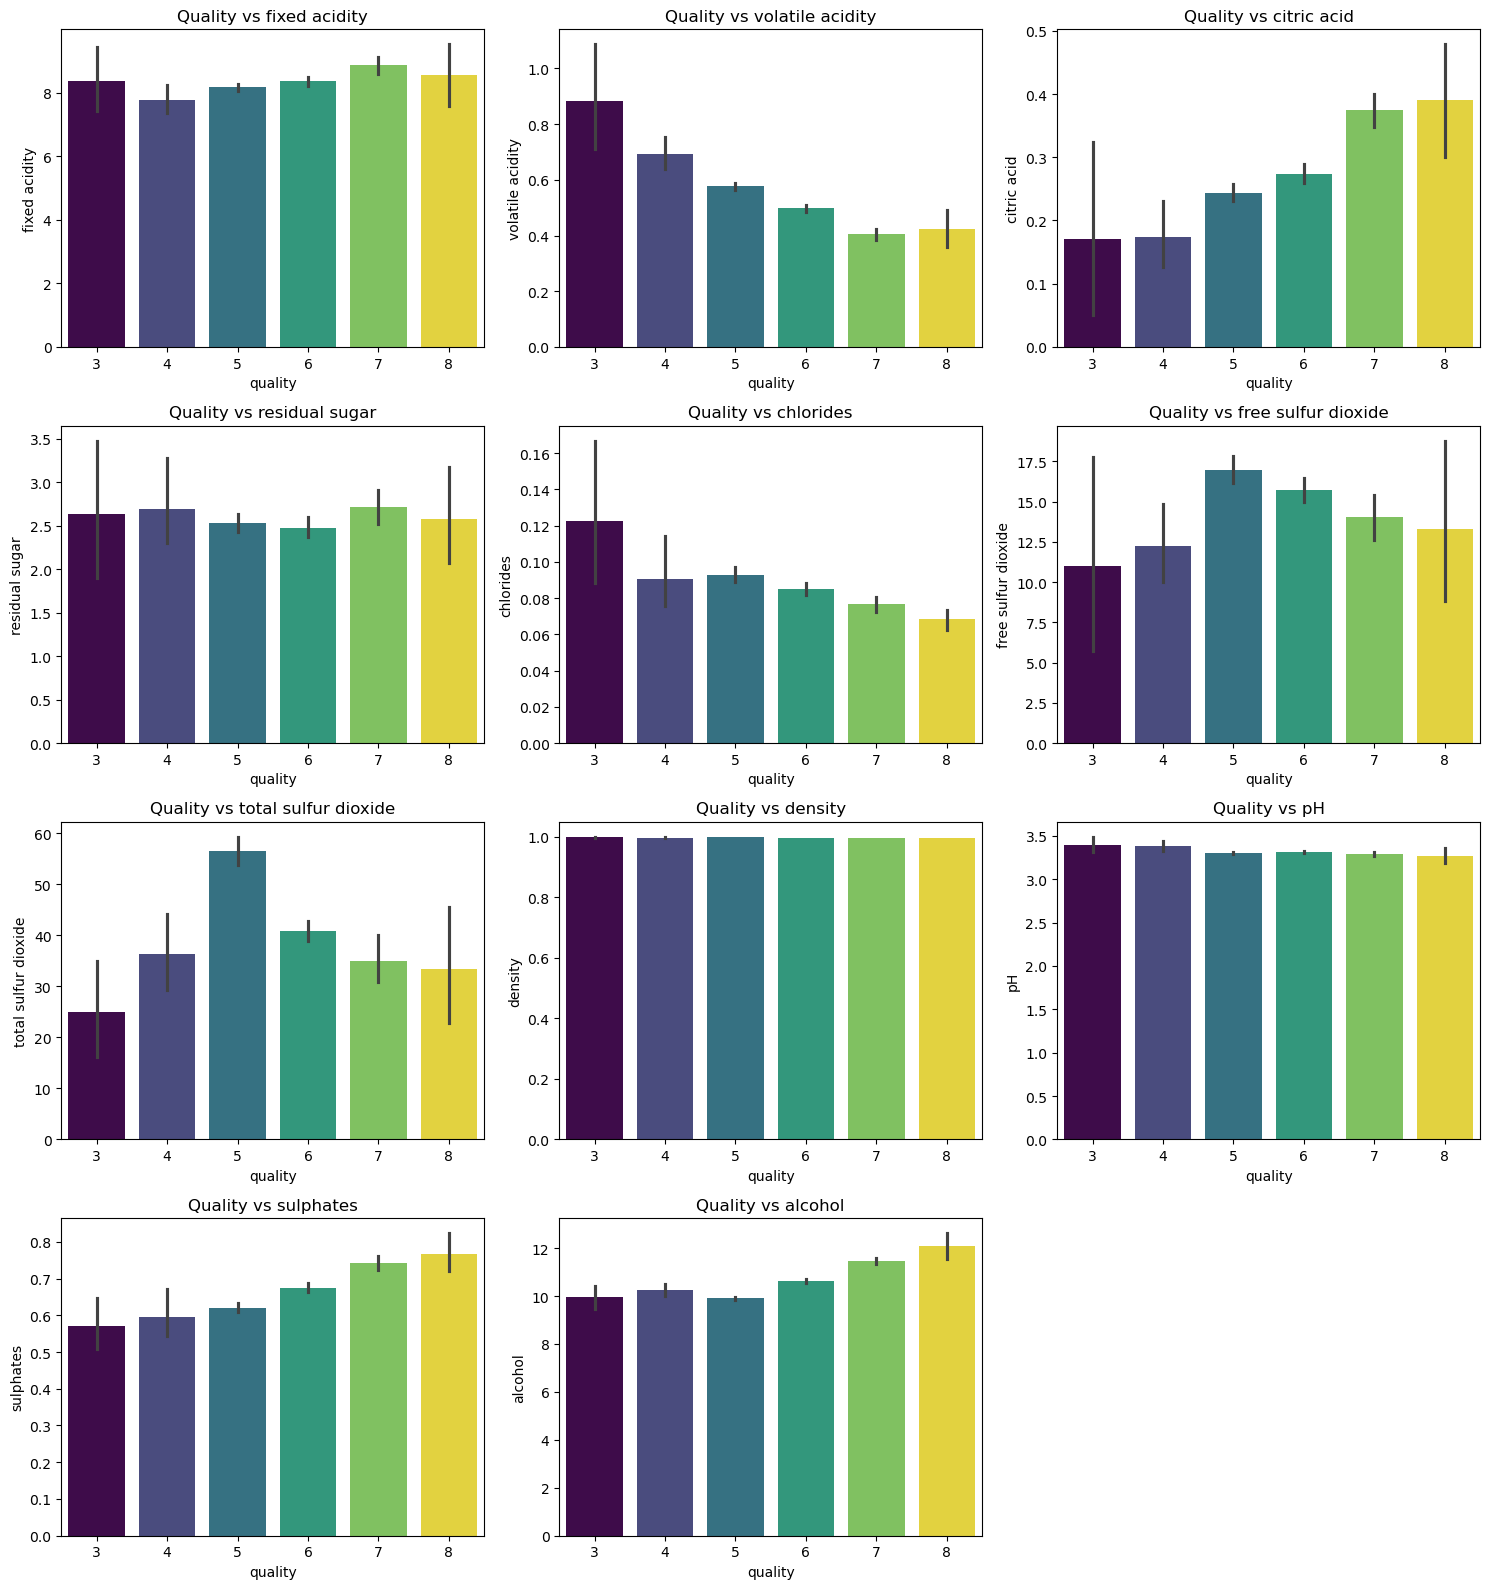

In [3]:
# Identify all numeric columns except the target 'quality'
features = wine.columns.drop('quality')

# Determine grid size (e.g., 3 columns wide)
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, column in enumerate(features):
    sns.barplot(x='quality', y=column, data=wine, hue='quality', palette='viridis', ax=axes[i])
    axes[i].set_title(f'Quality vs {column}')
    axes[i].get_legend().remove()

# Remove any empty subplots if the number of features isn't perfectly divisible
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

From what can be seen:
* Sulphates and Citric Acid have a positive correlation with Wine quality
* Alcohol has a very slight positive correlation with Wine Quality
* Volatile Acidity and Chlorides have a negative correlation with Wine quality

##### Generating Binary classes for Wine Quality (good and bad)

In [4]:
bins = (2, 6.5, 8)
group_names = ['bad', 'good']
wine['quality'] = pd.cut(wine['quality'], bins = bins, labels = group_names)

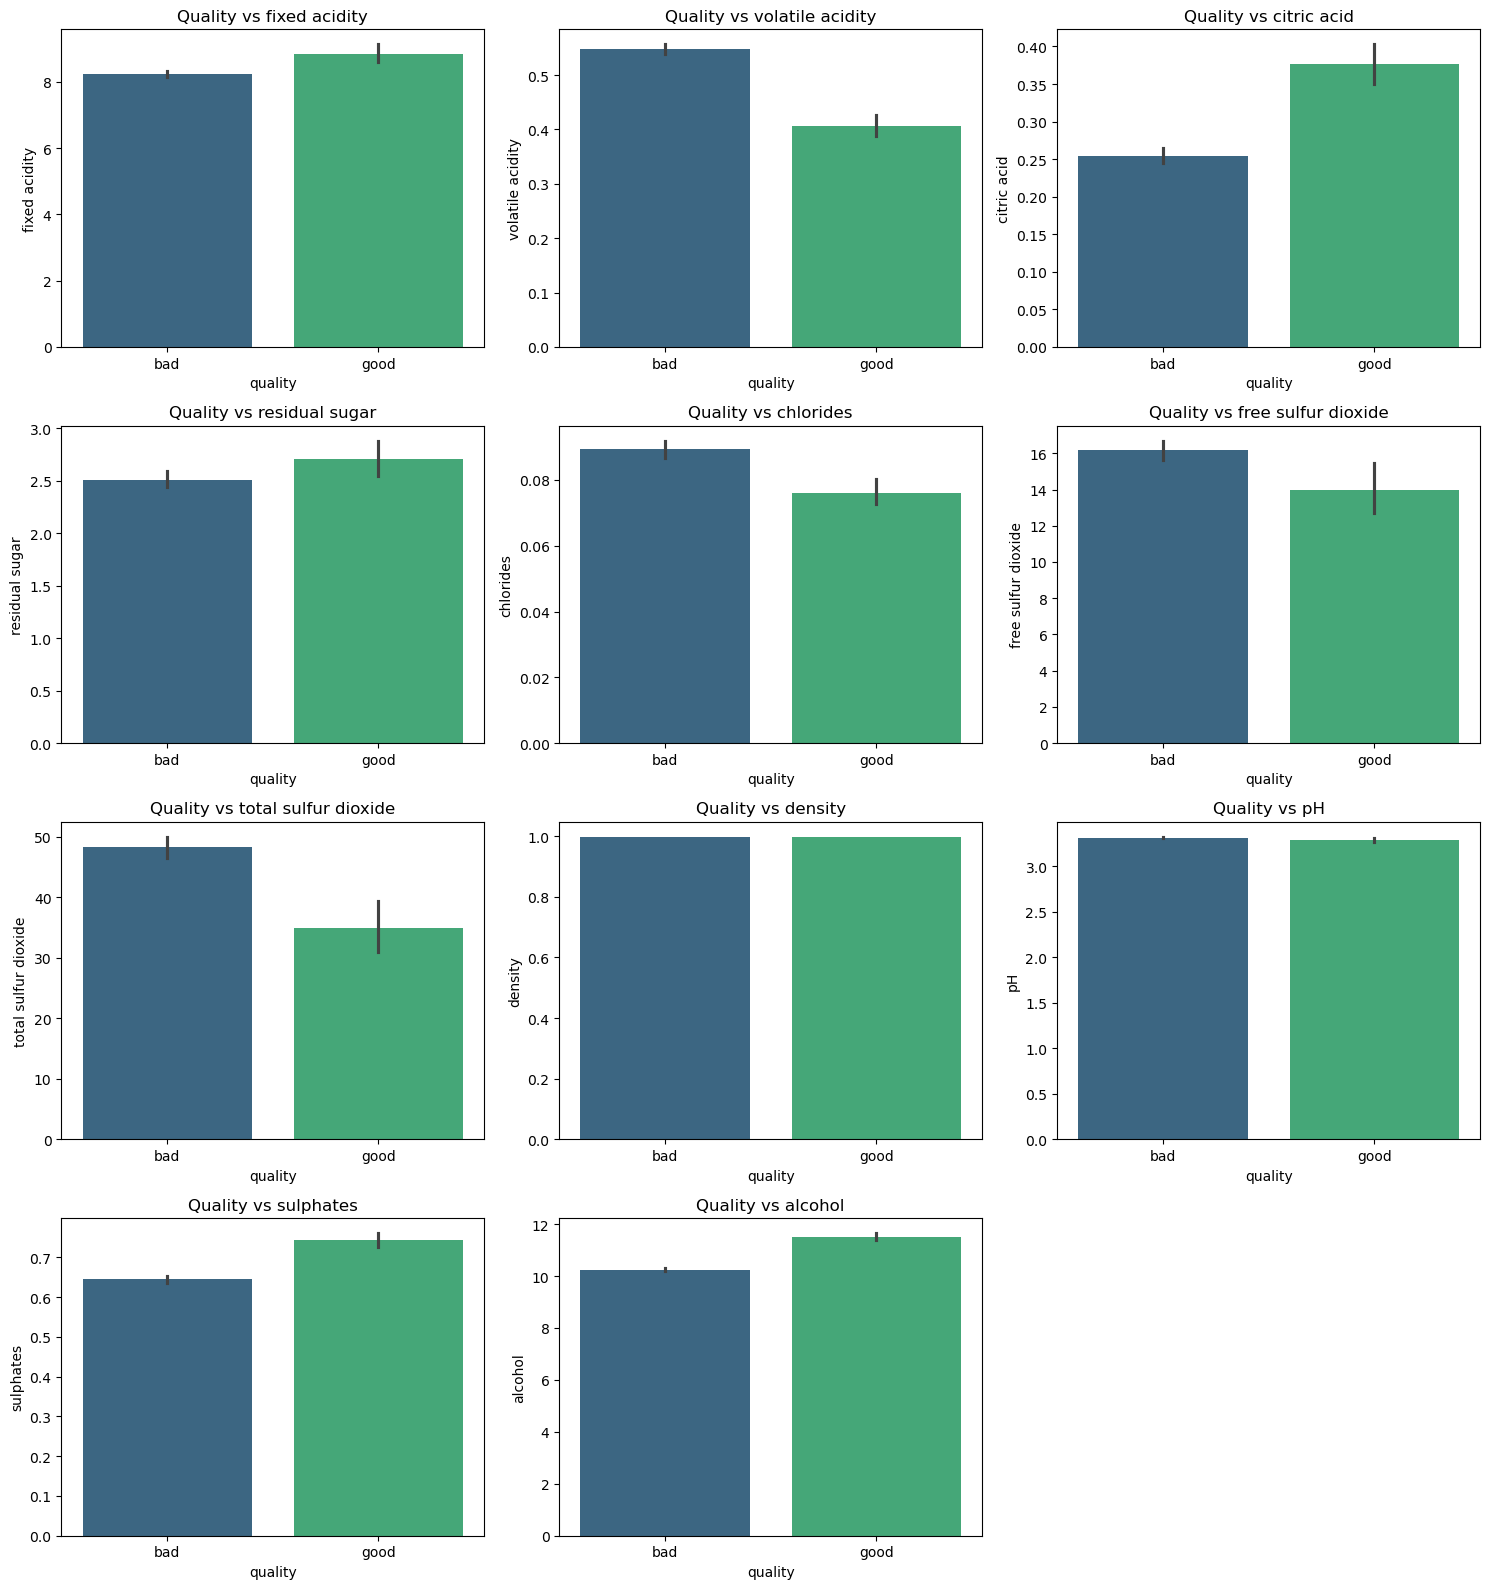

In [5]:
# Identify all numeric columns except the target 'quality'
features = wine.columns.drop('quality')

# Determine grid size (e.g., 3 columns wide)
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, column in enumerate(features):
    sns.barplot(x='quality', y=column, data=wine, hue='quality', palette='viridis', ax=axes[i])
    axes[i].set_title(f'Quality vs {column}')

# Remove any empty subplots if the number of features isn't perfectly divisible
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [6]:
wine['quality']

0       bad
1       bad
2       bad
3       bad
4       bad
       ... 
1594    bad
1595    bad
1596    bad
1597    bad
1598    bad
Name: quality, Length: 1599, dtype: category
Categories (2, object): ['bad' < 'good']

In [7]:
label_quality = LabelEncoder()

In [8]:
wine['quality'] = label_quality.fit_transform(wine['quality'])
wine['quality'].value_counts()

quality
0    1382
1     217
Name: count, dtype: int64

In [9]:
X = wine.drop('quality', axis = 1)
y = wine['quality']

## 3) Random Forest Model

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [11]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [12]:
rfc = RandomForestClassifier(n_estimators=100, random_state = 42)
rfc.fit(X_train, y_train)
pred_rfc = rfc.predict(X_test)

In [13]:
print("Accuaracy score =",accuracy_score(y_test, pred_rfc))
print(classification_report(y_test, pred_rfc))


Accuaracy score = 0.875
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       273
           1       0.67      0.30      0.41        47

    accuracy                           0.88       320
   macro avg       0.78      0.64      0.67       320
weighted avg       0.86      0.88      0.85       320



In [14]:
rfc_eval = cross_val_score(estimator = rfc, X = X_train, y = y_train, cv = 10, verbose=2)
rfc_eval.mean()

[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    2.3s finished


np.float64(0.911675688976378)

## 4) SVM Model

In [15]:
svc = SVC(random_state=42)
svc.fit(X_train, y_train)
pred_svc = svc.predict(X_test)

In [16]:
print("Accuaracy score =",accuracy_score(y_test, pred_svc))
print(classification_report(y_test, pred_svc))

Accuaracy score = 0.875
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       273
           1       0.71      0.26      0.38        47

    accuracy                           0.88       320
   macro avg       0.80      0.62      0.65       320
weighted avg       0.86      0.88      0.85       320



### 4.1) Hyperparameter tuning with SVM

In [17]:
param = {
    'C': [0.1,0.8,0.9,1,1.1,1.2,1.3,1.4],
    'kernel':['linear', 'rbf'],
    'gamma' :[0.1,0.8,0.9,1,1.1,1.2,1.3,1.4]
}
grid_svc = GridSearchCV(svc,param, cv=10, verbose=2)

In [18]:
grid_svc.fit(X_train, y_train)

Fitting 10 folds for each of 128 candidates, totalling 1280 fits
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 0.8, ...], 'gamma': [0.1, 0.8, ...], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1.2


In [19]:
print(f"Best Parameters: {grid_svc.best_params_}")

Best Parameters: {'C': 1.2, 'gamma': 0.9, 'kernel': 'rbf'}


In [20]:
pred = grid_svc.predict(X_test)
print("Accuaracy score =", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuaracy score = 0.896875
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       273
           1       0.89      0.34      0.49        47

    accuracy                           0.90       320
   macro avg       0.89      0.67      0.72       320
weighted avg       0.90      0.90      0.88       320



Accuracy score has increased to **90%**

### 4.2) SVM with SMOTE (for unbalanced datasets)

The dataset is unbalanced as there's alot more "bad" classes than "good"\
Using SMOTE can help improve the predictions for the minotiry class "good"

In [21]:
from imblearn.over_sampling import SMOTE 

# 1. Initialize SMOTE
# random_state ensures you get the exact same synthetic data every time you run it
smote = SMOTE(random_state=42)

# 2. Resample ONLY the training data
# This creates synthetic examples for fog, drizzle, and snow in the training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 3. Train the model on the newly balanced data
# Note: Do NOT use class_weight='balanced' here, as the data is already balanced
model = SVC(random_state=42)
model.fit(X_train_balanced, y_train_balanced)

# 4. Evaluate the model on the ORIGINAL, untouched test data
y_pred = model.predict(X_test)

# Display results
print("\n\u001b[1mClassification Report (With SMOTE):\u001b[0m")
print(classification_report(y_test, y_pred))


Classification Report (With SMOTE):
              precision    recall  f1-score   support

           0       0.97      0.86      0.91       273
           1       0.50      0.83      0.62        47

    accuracy                           0.85       320
   macro avg       0.73      0.84      0.77       320
weighted avg       0.90      0.85      0.87       320



In [22]:
grid_svc.fit(X_train_balanced, y_train_balanced)

Fitting 10 folds for each of 128 candidates, totalling 1280 fits
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.1s
[CV] END ....................C=0.1, gamma=0.1, kernel=linear; total time=   0.1s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.3s
[CV] END .......................C=0.1, gamma

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 0.8, ...], 'gamma': [0.1, 0.8, ...], 'kernel': ['linear', 'rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1.2


In [23]:
print(f"Best Parameters: {grid_svc.best_params_}")

Best Parameters: {'C': 1.2, 'gamma': 1.4, 'kernel': 'rbf'}


In [24]:
pred = grid_svc.predict(X_test)
print("Accuaracy score =", accuracy_score(y_test, pred))
print("\n\u001b[1mClassification Report (With SMOTE + Hyperparameter tuning):\u001b[0m")
print(classification_report(y_test, pred))

Accuaracy score = 0.9125

Classification Report (With SMOTE + Hyperparameter tuning):
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       273
           1       0.83      0.51      0.63        47

    accuracy                           0.91       320
   macro avg       0.87      0.75      0.79       320
weighted avg       0.91      0.91      0.90       320



The Accuracy has increased to **91%** and the f1_macro score has increased to **79%**

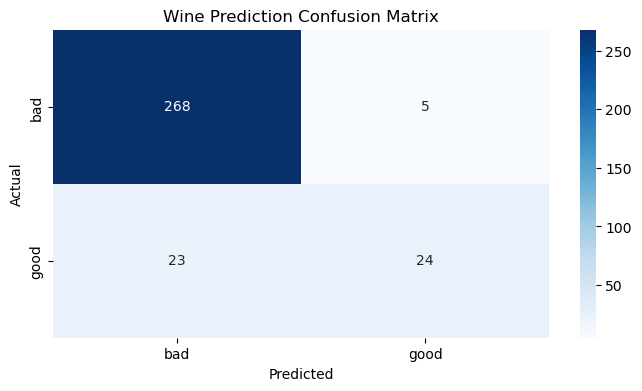

In [25]:
# Visual Check: Plot the Confusion Matrix to see exactly where errors happen
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_quality.classes_, yticklabels=label_quality.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Wine Prediction Confusion Matrix')
plt.show()